### <b> probar si un nuevo algoritmo de trading realmente genera rendimientos positivos o si sus ganancias son pura suerte (azar). </b>

In [1]:
import numpy as np
import scipy.stats as stats

# 0. INICIO: Configuración del Escenario
np.random.seed(42)  # Para que los resultados sean replicables

# Parámetros poblacionales simulados
# Simulamos que el algoritmo SÍ es bueno y genera un 0.05% diario (aprox 12.6% anual)
true_mean = 0.0005  
volatility = 0.0120  # Volatilidad diaria del 1.2%
sample_size = 250    # 1 año de datos bursátiles (n > 30, usaremos Z-test)

# Generamos los datos de la muestra (retornos diarios)
retornos_muestra = np.random.normal(true_mean, volatility, sample_size)

# ==========================================
# 1. CONCEPTOS 1 y 2: Hipótesis y Estadístico
# ==========================================
# H0: El algoritmo NO genera valor (Media de retornos = 0)
# H1: El algoritmo SÍ genera valor (Media de retornos > 0) -> Prueba de 1 cola
mu_0 = 0.0000  

# Calculamos los momentos muestrales
media_muestral = np.mean(retornos_muestra)
desviacion_muestral = np.std(retornos_muestra, ddof=1)
error_estandar = desviacion_muestral / np.sqrt(sample_size)

# Calculamos el Estadístico de Prueba (Z-score por el tamaño de muestra)
z_stat = (media_muestral - mu_0) / error_estandar


# 2. DESENLACE: Umbrales y Reglas de Decisión

alpha = 0.05  # Nivel de significancia (Error Tipo I máximo tolerable)

# Método 1: Valor Crítico
valor_critico = stats.norm.ppf(1 - alpha)

# Método 2: Valor p (p-value)
# Al ser de una cola derecha, es 1 menos la probabilidad acumulada
p_value = 1 - stats.norm.cdf(z_stat)


# 3. Intervalo de Confianza y Reporte
#
# Intervalo de confianza del 95% para la media real
conf_level = 0.95
z_critico_dos_colas = stats.norm.ppf(1 - (1 - conf_level)/2)
margen_error = z_critico_dos_colas * error_estandar
intervalo_confianza = (media_muestral - margen_error, media_muestral + margen_error)

# Imprimir el análisis cuantitativo
print(f"--- RESULTADOS DEL ANÁLISIS (MUESTRA DE {sample_size} DÍAS) ---")
print(f"Media Muestral: {media_muestral:.6f} ({media_muestral*100:.4f}%)")
print(f"Error Estándar: {error_estandar:.6f}")
print(f"Estadístico de Prueba (Z): {z_stat:.4f}")
print(f"Valor Crítico (Z alfa): {valor_critico:.4f}")
print(f"Valor p (p-value): {p_value:.4f} ({p_value*100:.2f}%)")
print(f"Intervalo de Confianza 95%: [{intervalo_confianza[0]:.6f}, {intervalo_confianza[1]:.6f}]")
print("-" * 50)

# Conclusión de la historia
if z_stat > valor_critico:
    print("CONCLUSIÓN: RECHAZAMOS la Hipótesis Nula (H0).")
    print("Hay evidencia estadística suficiente para afirmar que el algoritmo genera valor.")
else:
    print("CONCLUSIÓN: FRACASAMOS EN RECHAZAR la Hipótesis Nula (H0).")
    print("No hay evidencia suficiente; los retornos podrían ser producto del azar.")


--- RESULTADOS DEL ANÁLISIS (MUESTRA DE 250 DÍAS) ---
Media Muestral: 0.000471 (0.0471%)
Error Estándar: 0.000733
Estadístico de Prueba (Z): 0.6423
Valor Crítico (Z alfa): 1.6449
Valor p (p-value): 0.2603 (26.03%)
Intervalo de Confianza 95%: [-0.000966, 0.001908]
--------------------------------------------------
CONCLUSIÓN: FRACASAMOS EN RECHAZAR la Hipótesis Nula (H0).
No hay evidencia suficiente; los retornos podrían ser producto del azar.


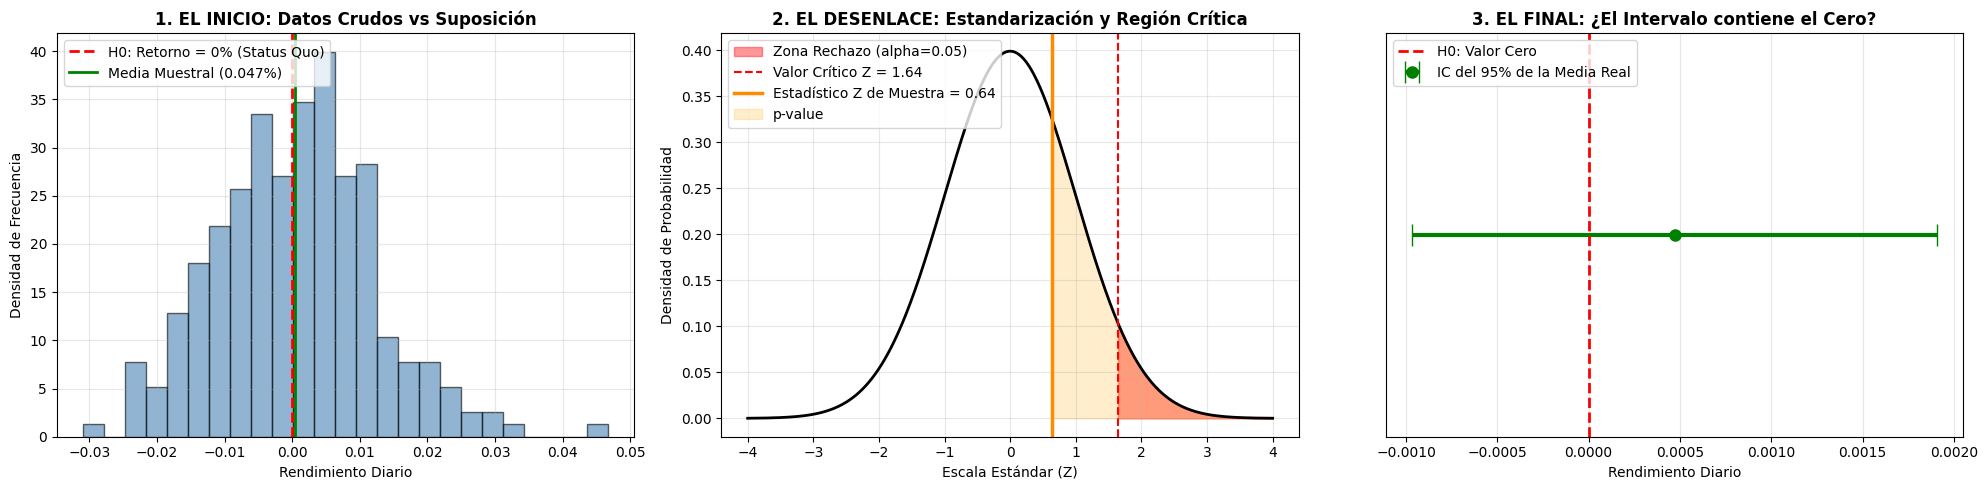

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 0. CONFIGURACIÓN DE DATOS (Mismo escenario)
# ==========================================
np.random.seed(42)
true_mean, volatility, sample_size = 0.0005, 0.0120, 250
retornos_muestra = np.random.normal(true_mean, volatility, sample_size)

# Cálculos estadísticos básicos
media_muestral = np.mean(retornos_muestra)
desviacion_muestral = np.std(retornos_muestra, ddof=1)
error_estandar = desviacion_muestral / np.sqrt(sample_size)

# Parámetros de la prueba (H0: mu = 0)
z_stat = (media_muestral - 0) / error_estandar
alpha = 0.05
valor_critico = stats.norm.ppf(1 - alpha)

# Configurar lienzo de gráficos 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# GRÁFICO 1: EL INICIO - Datos Crudos vs H0
# ==========================================
ax = axes[0]
ax.hist(retornos_muestra, bins=25, alpha=0.6, color='steelblue', edgecolor='black', density=True)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H0: Retorno = 0% (Status Quo)')
ax.axvline(media_muestral, color='green', linestyle='-', linewidth=2, label=f'Media Muestral ({media_muestral*100:.3f}%)')
ax.set_title("1. EL INICIO: Datos Crudos vs Suposición", fontsize=12, fontweight='bold')
ax.set_xlabel("Rendimiento Diario")
ax.set_ylabel("Densidad de Frecuencia")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ==========================================
# GRÁFICO 2: EL DESENLACE - Estadístico, Valor Crítico y p-Value
# ==========================================
ax = axes[1]
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x, 0, 1)
ax.plot(x, y, color='black', linewidth=2)

# Zona de rechazo (Alpha = 5%)
x_rechazo = np.linspace(valor_critico, 4, 100)
ax.fill_between(x_rechazo, stats.norm.pdf(x_rechazo, 0, 1), color='red', alpha=0.4, label=f'Zona Rechazo (alpha={alpha})')

# Líneas del examen FRM
ax.axvline(valor_critico, color='red', linestyle='--', label=f'Valor Crítico Z = {valor_critico:.2f}')
ax.axvline(z_stat, color='darkorange', linestyle='-', linewidth=2.5, label=f'Estadístico Z de Muestra = {z_stat:.2f}')

# Sombrear p-value (área a la derecha de Z observado)
x_p = np.linspace(z_stat, 4, 100)
ax.fill_between(x_p, stats.norm.pdf(x_p, 0, 1), color='orange', alpha=0.2, label='p-value')

ax.set_title("2. EL DESENLACE: Estandarización y Región Crítica", fontsize=12, fontweight='bold')
ax.set_xlabel("Escala Estándar (Z)")
ax.set_ylabel("Densidad de Probabilidad")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# ==========================================
# GRÁFICO 3: EL FINAL - Intervalo de Confianza (95%)
# ==========================================
ax = axes[2]
z_ic = stats.norm.ppf(1 - (1 - 0.95)/2)
margen = z_ic * error_estandar
ic_inf, ic_sup = media_muestral - margen, media_muestral + margen

# Dibujar la línea del intervalo y la media
ax.errorbar(media_muestral, 1, xerr=margen, fmt='o', color='green', markersize=8, capsize=8, linewidth=3, label='IC del 95% de la Media Real')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='H0: Valor Cero')

ax.set_ylim(0.5, 1.5)
ax.set_yticks([])  # Quitar eje Y innecesario
ax.set_title("3. EL FINAL: ¿El Intervalo contiene el Cero?", fontsize=12, fontweight='bold')
ax.set_xlabel("Rendimiento Diario")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Desplegar los tres gráficos
plt.tight_layout()
plt.show()
